# Introduction

We focus on analysing the binary classification dataset, and apply the following steps:
1. Load the dataset and analyze the distribution of classes.
2. Display sample images from each class.
3. Compute the mean and standard deviation of pixel values for each class.
4. Detect and analyze blurred images in the dataset.
5. Visualize the distribution of blurred and non-blurred images.
6. Demonstrate data augmentation and normalization techniques.

## Imports

In [1]:
import os
import matplotlib.pyplot as plt
import cv2
import random
import numpy as np
import pandas as pd
from torchvision.transforms import v2
from PIL import Image
import torch
from nazi_symbols_classification.training.data_preparation import get_image_paths

## Load and Analyze Dataset

In [3]:
dir_name = os.path.dirname(os.getcwd())
image_files = get_image_paths(f"{dir_name}/datasets/nazi-symbols-detection-original", 
                              ("train", "test", "valid"))
print(f"Total Images: {len(image_files)}")

Total Images: 101389


In [4]:
nazi_images = [image for image in image_files if "non-nazi" not in image]
non_nazi_images = [image for image in image_files if "non-nazi" in image]
len(nazi_images), len(non_nazi_images)

(1954, 99435)

### Display Sample Images

Nazi Sample images 

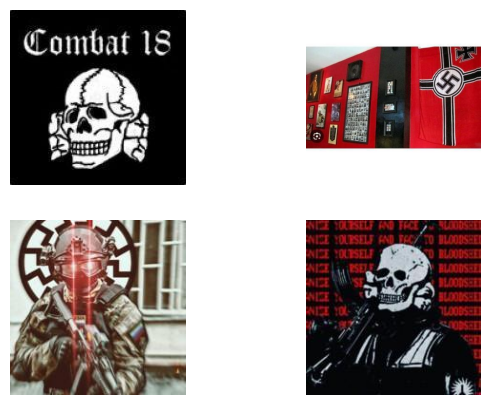

In [5]:
sample_images = random.sample(nazi_images, 4)
fig, axes = plt.subplots(2, 2, figsize=(7, 5))
for i, ax_l in enumerate(axes):
    for j, ax in enumerate(ax_l):
        img_file = sample_images[i * 2 + j]
        img = cv2.imread(img_file)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        ax.imshow(img)
        ax.axis("off")
plt.savefig('nazi-examples.png')
plt.show()

Non-Nazi Sample images

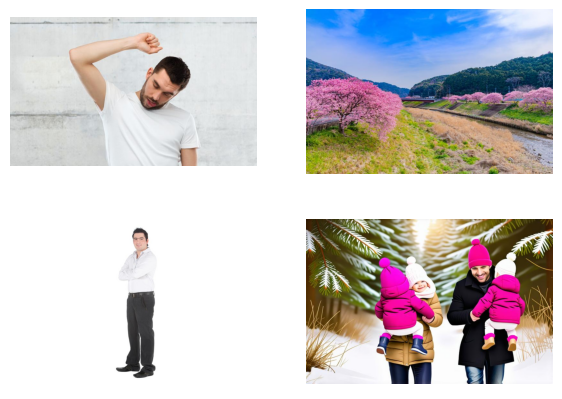

In [6]:
sample_images = random.sample(non_nazi_images, 4)
fig, axes = plt.subplots(2, 2, figsize=(7, 5))
for i, ax_l in enumerate(axes):
    for j, ax in enumerate(ax_l):
        img_file = sample_images[i * 2 + j]
        img = cv2.imread(img_file)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        ax.imshow(img)
        ax.axis("off")
plt.savefig('non-nazi-examples.png')
plt.show()

### Analyze Image Class Distribution

In [7]:
labels = [os.path.basename(os.path.dirname(image_file)) for image_file in image_files]

In [9]:
df = pd.DataFrame({"path": image_files, "label": labels})
df["label"] = df["label"].replace("nazi-symbol", "nazi")
df.head()

,path,label
0,/home/zhiwei/Projects/nazi-symbols-classificat...,non-nazi
1,/home/zhiwei/Projects/nazi-symbols-classificat...,non-nazi
2,/home/zhiwei/Projects/nazi-symbols-classificat...,non-nazi
3,/home/zhiwei/Projects/nazi-symbols-classificat...,non-nazi
4,/home/zhiwei/Projects/nazi-symbols-classificat...,non-nazi


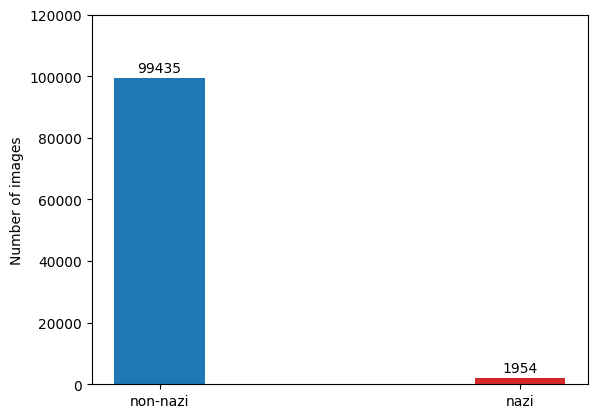

In [12]:
fig, ax = plt.subplots()

img_cls, img_number = tuple(zip(*df["label"].value_counts().to_dict().items()))
width = 0.25
x = np.arange(len(df["label"].value_counts()))  # the label locations

bar_colors = ['tab:blue', 'tab:red']

rects = ax.bar(img_cls, img_number, width, color=bar_colors)
ax.bar_label(rects, padding=2)

ax.set_ylabel('Number of images')
# ax.set_title('Image Class Distribution')
ax.set_ylim(top=120000)

plt.savefig('nazi-detection-distribution.png')
plt.show()

### Compute mean and std deviation across dataset

In [13]:
nazi_means, nazi_stds = [], []
non_nazi_means, non_nazi_stds = [], []
for i, img_file in enumerate(image_files):
    img = cv2.imread(img_file)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) / 255.0
    if labels[i] == "non-nazi":
        non_nazi_means.append(np.mean(img, axis=(0, 1)))
        non_nazi_stds.append(np.std(img, axis=(0, 1)))
    else:
        nazi_means.append(np.mean(img, axis=(0, 1)))
        nazi_stds.append(np.std(img, axis=(0, 1)))

nazi_mean = np.mean(nazi_means, axis=0)
nazi_std = np.mean(nazi_stds, axis=0)

non_nazi_mean = np.mean(non_nazi_means, axis=0)
non_nazi_std = np.mean(non_nazi_stds, axis=0)

print(f"Nazi images: \nMean: {nazi_mean}, Std Dev: {nazi_std}")
print(f"Non nazi images: \nMean: {non_nazi_mean}, Std Dev: {non_nazi_std}")

Nazi images: 
Mean: [0.44945447 0.44945447 0.44945447], Std Dev: [0.28833532 0.28833532 0.28833532]
Non nazi images: 
Mean: [0.5943972  0.56588367 0.51155744], Std Dev: [0.26253006 0.25983966 0.27455945]


In [18]:
overall_mean = np.mean(nazi_means + non_nazi_means, axis=0)
overall_std = np.mean(nazi_means + non_nazi_stds, axis=0)

print(f"Overall: \nMean: {overall_mean}, Std Dev: {overall_std}")

Overall: 
Mean: [0.58803015 0.56076917 0.50882938], Std Dev: [0.27074128 0.26816906 0.28224224]


### Detect Blurred Images and Analyze Blurred Image Distribution

In [ ]:
def detect_blur(img_path, threshold=100):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    laplacian_var = cv2.Laplacian(img, cv2.CV_64F).var()
    return laplacian_var < threshold

blurred_images = [f for f in image_files if detect_blur(f)]
non_nazi_blurred_images = [f for f in blurred_images if "non-nazi" in f]

In [21]:
print(f"Blurred Images: {len(blurred_images)}(nazi: {len(blurred_images) - len(non_nazi_blurred_images)}, non-nazi: {len(non_nazi_blurred_images)})")

Blurred Images: 6007(nazi: 18, non-nazi: 5989)


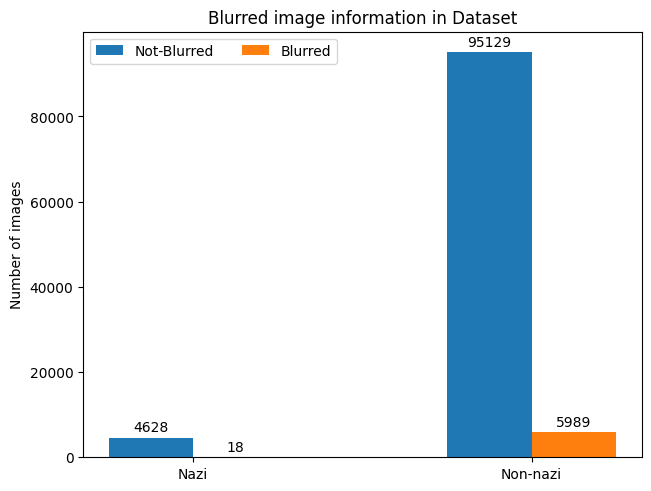

In [48]:
species = ("Nazi", "Non-nazi",)
weight_counts = {
    "Not-Blurred": np.array([len(nazi_images) - (len(blurred_images) - len(non_nazi_blurred_images)), len(non_nazi_images) - len(non_nazi_blurred_images)]),
    "Blurred": np.array([len(blurred_images) - len(non_nazi_blurred_images), len(non_nazi_blurred_images)]),
}

x = np.arange(len(species))  # the label locations
width = 0.25  # the width of the bars
multiplier = 0

fig, ax = plt.subplots(layout='constrained')

for attribute, measurement in weight_counts.items():
    offset = width * multiplier
    rects = ax.bar(x + offset, measurement, width, label=attribute)
    ax.bar_label(rects, padding=len(species))
    multiplier += 1

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Number of images')
ax.set_title('Blurred image information in Dataset')
ax.set_xticks(x + (width / 2) * (len(weight_counts) - 1), species)
ax.legend(loc='upper left', ncols=len(species))

plt.show()

## Data Augmentation and Normalization Examples

The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.


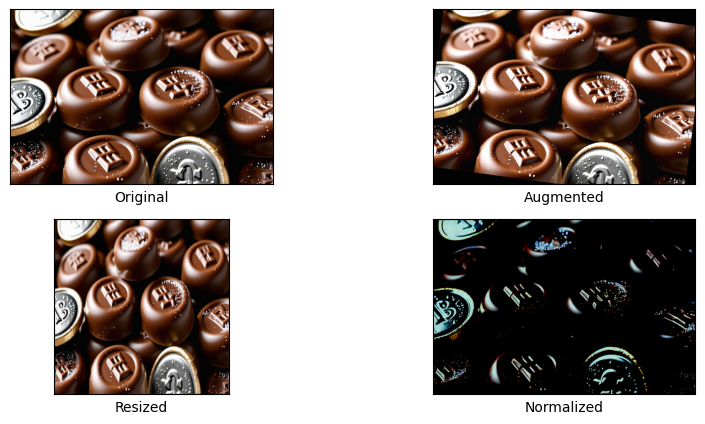

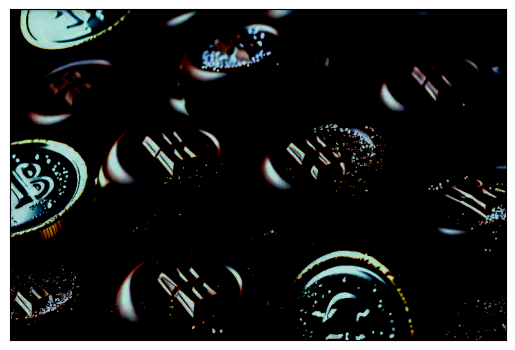

In [68]:
transform = v2.Compose([
    v2.ToTensor()
])

img_tr = transform(img)
mean, std = img_tr.mean([1,2]), img_tr.std([1,2])

aug_transform = v2.Compose([
    v2.RandomHorizontalFlip(),
    v2.RandomRotation(20),
    v2.ColorJitter(brightness=0.2, contrast=0.2)
])

resize_transform = v2.Compose([
    v2.Resize((624, 624)),
])

normalization_transform = v2.Compose([
    v2.PILToTensor(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=mean, std=std),
])

img = Image.open(random.choice(image_files))



augmented_img = aug_transform(img)
resized_img = resize_transform(img)
normalized_img = normalization_transform(img)
normalized_img = np.array(normalized_img)
normalized_img = normalized_img.transpose(1, 2, 0)

plt.figure(figsize=(10,5))

plt.subplot(2,2,1)
plt.imshow(img)
plt.xticks([])
plt.yticks([])
plt.xlabel("Original")

plt.subplot(2,2,2)
plt.imshow(augmented_img)
plt.xticks([])
plt.yticks([])
plt.xlabel("Augmented")

plt.subplot(2,2,3)
plt.imshow(resized_img)
plt.xticks([])
plt.yticks([])
plt.xlabel("Resized")

plt.subplot(2,2,4)
plt.imshow(normalized_img)
plt.xticks([])
plt.yticks([])
plt.xlabel('Normalized')

# plt.savefig('augmentation-examples.png')
plt.show()

img.save("original-example.jpeg")
augmented_img.save("augmented-example.jpeg")
resized_img.save("resized-example.jpeg")

plt.imshow(normalized_img) #Needs to be in row,col order
plt.xticks([])
plt.yticks([])
plt.savefig("normalized-example.jpeg")
# Image.fromarray(normalized_img).save("normalized-example.jpeg")